
### Data and Package Import

The data was cleaned in the first file, `01_data_cleaning'. **\[1]**

In [1]:
# Imports and Paths

import os
import pandas as pd
import geopandas as gpd
from geopandas.tools import sjoin

data_root = r"C:\Users\Owner\Downloads\Geospatial Data Science\Final Project\Data"

osm_dir   = os.path.join(data_root, "OSM_PA")
nfhl_root = os.path.join(data_root, "NFHL")

substations_path = os.path.join(osm_dir, "substations_sepa_clean.gpkg")


In [2]:
# Load Cleaned Substations
substations = gpd.read_file(substations_path, layer="substations_sepa")

substations.crs, substations.head(), len(substations)


(<Projected CRS: EPSG:2272>
 Name: NAD83 / Pennsylvania South (ftUS)
 Axis Info [cartesian]:
 - X[east]: Easting (US survey foot)
 - Y[north]: Northing (US survey foot)
 Area of Use:
 - name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
 - bounds: (-80.53, 39.71, -74.72, 41.18)
 Coordinate Operation:
 - name: SPCS83 Pennsylvania South zone (US survey foot)
 - method: Lambert Conic Conformal (2SP)
 Datum: North American Datum 1983
 - Ellipsoid: GRS 1980
 - Prime Meridian: Greenwich,
                     name operator              voltage          substation  \
 0                   None     None                 None  minor_distribution   
 1     

In [3]:
# NFHL fld hzrd plygns
flood_layers = []

for county_folder in os.listdir(nfhl_root):
    county_path = os.path.join(nfhl_root, county_folder)
    flood_path = os.path.join(county_path, "S_FLD_HAZ_AR.shp")

    if os.path.exists(flood_path):
        gdf = gpd.read_file(flood_path)
        gdf["county_nfhl"] = county_folder
        flood_layers.append(gdf)
    else:
        print(f"Warning: no S_FLD_HAZ_AR.shp in {county_folder}")

len(flood_layers)


5

In [4]:
flood_all = gpd.GeoDataFrame(
    pd.concat(flood_layers, ignore_index=True),
    crs=flood_layers[0].crs
)

flood_all.crs 


<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [5]:
flood_all.shape, flood_all.columns[:10]

((15271, 21),
 Index(['DFIRM_ID', 'VERSION_ID', 'FLD_AR_ID', 'STUDY_TYP', 'FLD_ZONE',
        'ZONE_SUBTY', 'SFHA_TF', 'STATIC_BFE', 'V_DATUM', 'DEPTH'],
       dtype='object'))

In [6]:
# fld reprojection
flood_all_2272 = flood_all.to_crs(substations.crs)
flood_all_2272.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

### Flood Zone and Substation Analysis

#### Quick Overview

In [7]:
#Step 0.1: Flood Zone Count
flood_all_2272["FLD_ZONE"].value_counts().head(20)

FLD_ZONE
X             8315
AE            6284
A              666
OPEN WATER       4
AO               2
Name: count, dtype: int64

In [8]:
#Step 0.2: Classifying High Risk
high_risk = ["AE", "A", "AO"]

flood_high = flood_all_2272[
    flood_all_2272["FLD_ZONE"].isin(high_risk)
].copy()

flood_high["FLD_ZONE"].value_counts()


FLD_ZONE
AE    6284
A      666
AO       2
Name: count, dtype: int64

In [9]:
#Step 0.3: Joining Flood Zones and Substations
sub_flood = sjoin(
    substations,
    flood_high[["FLD_ZONE", "county_nfhl", "geometry"]],
    how="left",
    predicate="intersects"
)

sub_flood.head()

,name,operator,voltage,substation,voltage_list,geometry,index_right,FLD_ZONE,county_nfhl
0,None,None,None,minor_distribution,None,POINT (2694278.613 241426.895),NaN,NaN,NaN
1,Master Substation,PECO,230000;138000;69000,distribution,"['230000', '138000', '69000']",POINT (2686292.516 245575.081),NaN,NaN,NaN
2,Tabor Substation,PECO,230000;69000,distribution,"['230000', '69000']",POINT (2700364.179 266651.128),NaN,NaN,NaN
3,Callowhill Substation,PECO,138000,None,['138000'],POINT (2695212.95 238881.483),NaN,NaN,NaN
4,Packer Substation,PECO,69000,minor_distribution,['69000'],POINT (2693414.976 219769.854),NaN,NaN,NaN


In [10]:
sub_flood["FLD_ZONE"].isna().value_counts()

FLD_ZONE
True     275
False     23
Name: count, dtype: int64

In [11]:
sub_flood["FLD_ZONE"].value_counts(dropna=False)

FLD_ZONE
NaN    275
AE      22
A        1
Name: count, dtype: int64

In [12]:
#Step 0.4: Saving Analysis Layer
output_path = os.path.join(data_root, "substations_flood_exposure_SEPA.gpkg")

sub_flood.to_file(output_path, layer="substations_flood_exposure", driver="GPKG")

output_path

'C:\\Users\\Owner\\Downloads\\Geospatial Data Science\\Final Project\\Data\\substations_flood_exposure_SEPA.gpkg'

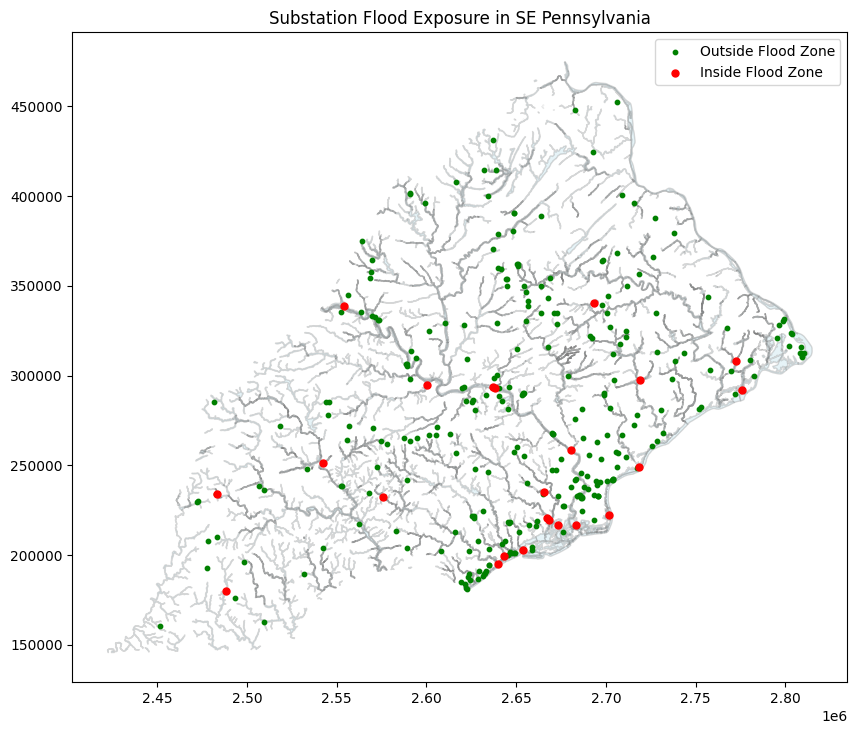

In [13]:
#Step 0.5: Maping Subsstations by Flood Risk
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

flood_high.plot(ax=ax, color="lightblue", edgecolor="gray", alpha=0.3)
sub_flood[sub_flood["FLD_ZONE"].isna()].plot(ax=ax, color="green", markersize=10, label="Outside Flood Zone")
sub_flood[sub_flood["FLD_ZONE"].notna()].plot(ax=ax, color="red", markersize=25, label="Inside Flood Zone")

ax.legend()
ax.set_title("Substation Flood Exposure in SE Pennsylvania")
plt.show()

In [15]:
#Step 0.6: Table of At Risk Substations
at_risk = sub_flood[sub_flood["FLD_ZONE"].notna()].copy()
at_risk[["name", "operator", "FLD_ZONE", "county_nfhl"]]

,name,operator,FLD_ZONE,county_nfhl
23,Penncoyd Substation,PECO,AE,philadelphia-county-nfhl
25,Penrose Substation,PECO,AE,philadelphia-county-nfhl
26,Island Road Substation,PECO,AE,philadelphia-county-nfhl
28,Southwark Substation,PECO,AE,philadelphia-county-nfhl
43,Richmond Substation,Amtrak,AE,philadelphia-county-nfhl
69,Barbadoes Substation,PECO,AE,montco-nfhl
84,None,PECO,AE,montco-nfhl
104,None,None,AE,montco-nfhl
107,None,None,AE,montco-nfhl
144,Upper Darby Substation,Philadelphia Electric Company,AE,delco-nfhl


#### Computing Distance to Flood Zone and Flood Severity

In [21]:
#Step 1.1: paranoid CRS check
substations.crs, flood_high.crs

(<Projected CRS: EPSG:2272>
 Name: NAD83 / Pennsylvania South (ftUS)
 Axis Info [cartesian]:
 - X[east]: Easting (US survey foot)
 - Y[north]: Northing (US survey foot)
 Area of Use:
 - name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
 - bounds: (-80.53, 39.71, -74.72, 41.18)
 Coordinate Operation:
 - name: SPCS83 Pennsylvania South zone (US survey foot)
 - method: Lambert Conic Conformal (2SP)
 Datum: North American Datum 1983
 - Ellipsoid: GRS 1980
 - Prime Meridian: Greenwich,
 <Projected CRS: EPSG:2272>
 Name: NAD83 / Pennsylvania South (ftUS)
 Axis Info [cartesian]:
 - X[east]: Easting (US survey foot)
 - Y[north]: Northing (US survey fo

In [22]:
#Step 1.2: Merged Flood Geometry
from shapely.ops import unary_union

flood_union = unary_union(flood_high.geometry)
type(flood_union)

shapely.geometry.multipolygon.MultiPolygon

In [23]:
#Step 1.3: Computing distance to flood in feet
substations["dist_to_flood_ft"] = substations.geometry.apply(
    lambda g: g.distance(flood_union)
)

substations["dist_to_flood_ft"].describe()

count      298.000000
mean      1660.860969
std       1648.638587
min          0.000000
25%        400.406239
50%       1208.481159
75%       2450.927764
max      11543.733177
Name: dist_to_flood_ft, dtype: float64

In [24]:
#Step 1.4: Join dist_to_flood_ft to sub_flood
sub_flood = sub_flood.join(
    substations["dist_to_flood_ft"],
    how="left"
)

sub_flood[["name", "FLD_ZONE", "dist_to_flood_ft"]].head()

,name,FLD_ZONE,dist_to_flood_ft
0,None,NaN,4523.375369
1,Master Substation,NaN,1187.737439
2,Tabor Substation,NaN,6073.712776
3,Callowhill Substation,NaN,4469.540859
4,Packer Substation,NaN,2901.122174


In [25]:
#Step 1.41: Checking the Indices
sub_flood["dist_to_flood_ft"].isna().sum()

np.int64(0)

In [26]:
#Step 1.5: Creating flood severity ordinal variable
import numpy as np

def severity_from_zone(zone):
    if zone in ("AE", "A"):
        return 3
    elif zone == "AO":
        return 2
    else:
        # includes NaN and anything else unexpected
        return 0

sub_flood["flood_severity"] = sub_flood["FLD_ZONE"].apply(severity_from_zone)

sub_flood[["FLD_ZONE", "flood_severity"]].value_counts().sort_index()

FLD_ZONE  flood_severity
A         3                  1
AE        3                 22
Name: count, dtype: int64

In [28]:
#Step 1.6: Binary Flood Indicator
sub_flood["in_flood_zone"] = (sub_flood["flood_severity"] > 0).astype(int)
sub_flood["in_flood_zone"].value_counts()

in_flood_zone
0    275
1     23
Name: count, dtype: int64

In [32]:
substations["in_flood_zone"] = substations.geometry.within(flood_union).astype(int)

In [33]:
substations["in_flood_zone"].value_counts()

in_flood_zone
0    275
1     23
Name: count, dtype: int64

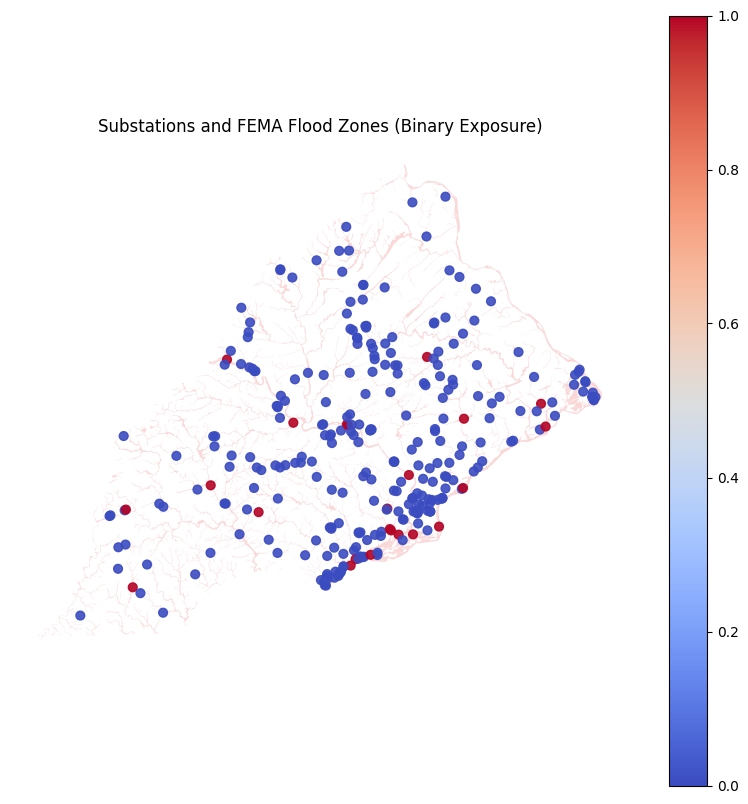

In [34]:
#Step 1.7: Visualization. Substations colored by flood exposure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot FEMA flood zones lightly for context
flood_high.plot(ax=ax, color='lightcoral', alpha=0.3, linewidth=0)

# Plot substations with 0/1 flood exposure
substations.plot(
    ax=ax,
    column="in_flood_zone",
    cmap="coolwarm",
    markersize=40,
    legend=True,
    alpha=0.9
)

ax.set_title("Substations and FEMA Flood Zones (Binary Exposure)")
ax.set_axis_off()


#### Spatial Hotspot Analysis for At-Risk Substations

In [35]:
#Step 2.1: Computing Nearest Non-Flooded Substation
from shapely.ops import nearest_points
from scipy.spatial import cKDTree

# Step 1: split into groups
flooded = sub_flood[sub_flood["in_flood_zone"] == 1].copy()
non_flooded = sub_flood[sub_flood["in_flood_zone"] == 0].copy()

# Extract coordinate arrays
flooded_coords = np.array([(geom.x, geom.y) for geom in flooded.geometry])
non_flooded_coords = np.array([(geom.x, geom.y) for geom in non_flooded.geometry])

# Step 2: build KDTree for fast nearest-neighbor lookup
tree = cKDTree(non_flooded_coords)

# Step 3: query nearest non-flooded station for each flooded station
distances, indexes = tree.query(flooded_coords, k=1)

# Attach distances back to the dataframe
flooded["dist_to_nearest_nonflood_ft"] = distances

# Summary
flooded["dist_to_nearest_nonflood_ft"].describe()

count       23.000000
mean      5655.351419
std       3297.219863
min        827.216501
25%       3604.343698
50%       4931.893304
75%       7728.558797
max      14313.976262
Name: dist_to_nearest_nonflood_ft, dtype: float64

(flesh out analysis) **No meaningful spatial clustering**

In [37]:
#Step 2.2: Adding Subsstation Operational Attributes
base_cols = [
    "name", "operator", "voltage_list", "substation",
    "in_flood_zone", "dist_to_flood_ft"
]

analysis_df = sub_flood[base_cols].copy()
analysis_df.head()


,name,operator,voltage_list,substation,in_flood_zone,dist_to_flood_ft
0,None,None,None,minor_distribution,0,4523.375369
1,Master Substation,PECO,"['230000', '138000', '69000']",distribution,0,1187.737439
2,Tabor Substation,PECO,"['230000', '69000']",distribution,0,6073.712776
3,Callowhill Substation,PECO,['138000'],None,0,4469.540859
4,Packer Substation,PECO,['69000'],minor_distribution,0,2901.122174


In [38]:
#Step 2.21: Flooded-only table
flooded_analysis_cols = base_cols + ["dist_to_nearest_nonflood_ft"]

flooded_analysis = flooded[flooded_analysis_cols].copy()
flooded_analysis.head()

,name,operator,voltage_list,substation,in_flood_zone,dist_to_flood_ft,dist_to_nearest_nonflood_ft
23,Penncoyd Substation,PECO,['69000'],yes,1,0.0,7204.582331
25,Penrose Substation,PECO,['230000'],None,1,0.0,8252.535262
26,Island Road Substation,PECO,"['230000', '69000']",yes,1,0.0,4773.576572
28,Southwark Substation,PECO,['69000'],generation,1,0.0,8490.799372
43,Richmond Substation,Amtrak,['138000'],traction,1,0.0,1063.291858


In [39]:
#Step 2.22: Ruh-roh substation field has weird values
analysis_df["substation"].value_counts(dropna=False)

substation
None                  101
minor_distribution     81
yes                    28
distribution           24
traction               21
transition             12
generation             11
transmission           11
industrial              9
Name: count, dtype: int64

In [50]:
#Step 2.23: Reclassification
def normalize_substation_class(x):
    if x in ["distribution", "minor_distribution"]:
        return "distribution"
    
    elif x in ["transmission", "transition"]:
        return "transmission"
    
    elif x in ["generation", "industrial"]:
        return "generation"
    
    # “yes” provides no engineering info → treat as unknown
    elif x in ["yes", None, "None"] or (isinstance(x, float) and np.isnan(x)):
        return "unknown"
    
    else:
        return "other"

analysis_df["substation_class"] = (analysis_df["substation"].apply(normalize_substation_class))

analysis_df["substation_class"].value_counts()


substation_class
unknown         129
distribution    105
transmission     23
other            21
generation       20
Name: count, dtype: int64

#### Substation Exposure Analysis

In [51]:
#Step 3.1 Operator Reclassifcation
def clean_operator(op):
    if op is None:
        return "unknown"

    op = str(op).strip()

    # Normalize different PECO variants
    if op in ["PECO", "Philadelphia Electric Company", "PECO;SEPTA", "PECO;"]:
        return "PECO"

    # Normalize SEPTA
    if "SEPTA" in op:
        return "SEPTA"

    # Normalize Amtrak
    if "Amtrak" in op:
        return "Amtrak"

    # Everything else:
    return "other_operator"

analysis_df["operator_clean"] = analysis_df["operator"].apply(clean_operator)

analysis_df["operator_clean"].value_counts()


operator_clean
PECO              140
unknown           109
other_operator     30
Amtrak             15
SEPTA               4
Name: count, dtype: int64

*See Appendix for details on the other operators*

In [52]:
#Step 3.2: Operator Exposure
operator_exposure_clean = (
    analysis_df.groupby("operator_clean")["in_flood_zone"]
    .agg(["count", "sum"])
    .rename(columns={"count": "total_substations", "sum": "flooded_substations"})
)

operator_exposure_clean["pct_flooded"] = (
    operator_exposure_clean["flooded_substations"] /
    operator_exposure_clean["total_substations"]
)

operator_exposure_clean.sort_values("pct_flooded", ascending=False)


,total_substations,flooded_substations,pct_flooded
operator_clean,,,
unknown,109,11,0.100917
PECO,140,11,0.078571
Amtrak,15,1,0.066667
SEPTA,4,0,0.000000
other_operator,30,0,0.000000


In [53]:
#Step 3.3 Converting voltage_list into maximum voltage (kV)
import re

def parse_voltage_list(v):
    # Handle missing
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return np.nan
    
    # Case 1: already a Python list of strings or ints
    if isinstance(v, list):
        try:
            return max(int(x) for x in v)
        except Exception:
            return np.nan
    
    # Case 2: strings – including "['230000','69000']" or "230000;69000" etc.
    if isinstance(v, str):
        # extract all digit groups as candidate voltages
        nums = re.findall(r"\d+", v)
        if len(nums) == 0:
            return np.nan
        try:
            return max(int(x) for x in nums)
        except Exception:
            return np.nan
    
    # Anything else
    return np.nan

# Apply parser
analysis_df["max_voltage"] = analysis_df["voltage_list"].apply(parse_voltage_list)
analysis_df["max_voltage_kv"] = analysis_df["max_voltage"] / 1000.0

analysis_df["max_voltage_kv"].describe()

count    185.000000
mean     160.032432
std       92.822113
min       12.000000
25%       69.000000
50%      138.000000
75%      230.000000
max      500.000000
Name: max_voltage_kv, dtype: float64

In [54]:
#Step 3.4: Binning and Comparing Voltage Classes
def classify_voltage(v):
    if np.isnan(v):
        return "unknown"
    elif v < 40:
        return "distribution"
    elif v < 100:
        return "subtransmission_low"
    elif v < 170:
        return "subtransmission_high"
    elif v < 300:
        return "transmission"
    else:
        return "extra_high_voltage"

analysis_df["voltage_class"] = analysis_df["max_voltage_kv"].apply(classify_voltage)

pd.crosstab(analysis_df["substation_class"],
    analysis_df["voltage_class"],
    normalize="index")


voltage_class,distribution,extra_high_voltage,subtransmission_high,subtransmission_low,transmission,unknown
substation_class,,,,,,
distribution,0.057143,0.000000,0.095238,0.266667,0.457143,0.123810
generation,0.000000,0.000000,0.100000,0.350000,0.500000,0.050000
other,0.047619,0.000000,0.809524,0.000000,0.000000,0.142857
transmission,0.000000,0.217391,0.217391,0.260870,0.260870,0.043478
unknown,0.015504,0.000000,0.031008,0.116279,0.100775,0.736434


In [56]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


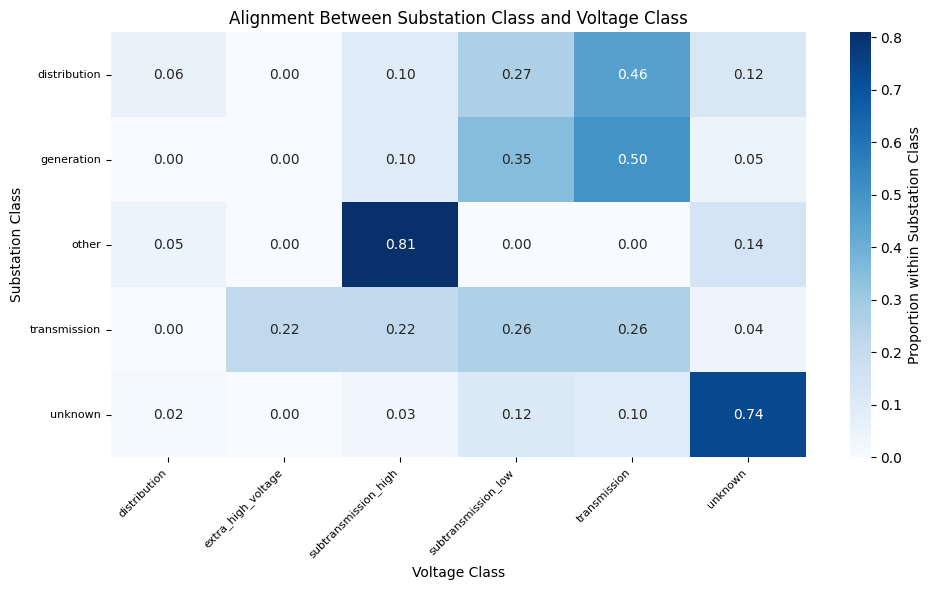

In [58]:
#Step 3.41: Voltage and Substation Type Innaccuracy Visulization
import seaborn as sns

# Use your existing crosstab table:
ct = pd.crosstab(
    analysis_df["substation_class"],
    analysis_df["voltage_class"],
    normalize="index"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    ct,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    cbar_kws={"label": "Proportion within Substation Class"}
)

plt.title("Alignment Between Substation Class and Voltage Class")
plt.xlabel("Voltage Class")
plt.ylabel("Substation Class")

# Shrink axis labels
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

In [61]:
#Step 3.5: Operator x Voltage Class Flood Exposure Table
# Creating grouped summary
operator_voltage_exposure = (
    analysis_df
    .groupby(["operator_clean", "voltage_class"])["in_flood_zone"]
    .agg(["count", "sum"])      # count = total substations, sum = flooded substations
    .rename(columns={"count": "total_substations",
                     "sum": "flooded_substations"})
    .reset_index()
)

# Computing percent flooded
operator_voltage_exposure["pct_flooded"] = (
    operator_voltage_exposure["flooded_substations"] /
    operator_voltage_exposure["total_substations"]
)

# Clean and sorted output
# Custom logical voltage ordering
voltage_order = [
    "distribution",
    "subtransmission_low",
    "subtransmission_high",
    "transmission",
    "extra_high_voltage",
    "unknown"
]

# Apply custom ordering to voltage_class
operator_voltage_exposure_ordered = (
    operator_voltage_exposure
    .assign(
        voltage_class = pd.Categorical(
            operator_voltage_exposure["voltage_class"],
            categories = voltage_order,
            ordered = True
        )
    )
    .sort_values(["operator_clean", "voltage_class"])
    .reset_index(drop=True)
)

operator_voltage_exposure_ordered

,operator_clean,voltage_class,total_substations,flooded_substations,pct_flooded
0,Amtrak,subtransmission_high,14,1,0.071429
1,Amtrak,unknown,1,0,0.000000
2,PECO,distribution,6,0,0.000000
3,PECO,subtransmission_low,24,4,0.166667
4,PECO,subtransmission_high,18,2,0.111111
5,PECO,transmission,65,3,0.046154
6,PECO,extra_high_voltage,3,0,0.000000
7,PECO,unknown,24,2,0.083333
8,SEPTA,subtransmission_high,2,0,0.000000
9,SEPTA,unknown,2,0,0.000000


C:\Users\Owner\AppData\Local\Temp\ipykernel_26504\4071848357.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


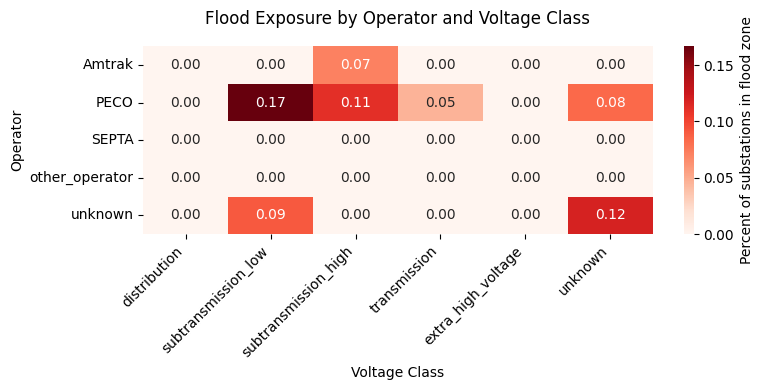

In [67]:
#Step 3.51: Heatmap
# Pivot to operator (rows) × voltage_class (cols), value = pct_flooded
op_vol_pivot = (
    operator_voltage_exposure_ordered
    .pivot_table(
        index="operator_clean",
        columns="voltage_class",
        values="pct_flooded",
        fill_value=0.0
    )
    # make sure columns are in the logical voltage order we defined earlier
    .reindex(columns=voltage_order)
)

plt.figure(figsize=(8, 4))  # tweak size as needed

ax = sns.heatmap(
    op_vol_pivot,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=op_vol_pivot.values.max(),  # scale to your max pct_flooded
    cbar_kws={"label": "Percent of substations in flood zone"}
)

ax.set_title("Flood Exposure by Operator and Voltage Class", pad=16)
ax.set_xlabel("Voltage Class")
ax.set_ylabel("Operator")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Note: Percentage is from 0 to 1 not 0 to 100**

#### Composite Flood Exposure Score

In [71]:
#Step 4.1: Building Feature Matrix off analysis_df copy

# Initialize DTNNF column as it's not in analysis
analysis_df["dist_to_nearest_nonflood_ft"] = np.nan

# Fill it for flooded substations
analysis_df.loc[flooded.index, "dist_to_nearest_nonflood_ft"] = (
    flooded["dist_to_nearest_nonflood_ft"]
)
# Feature Matrix Columna
num_cols = [
    "in_flood_zone",                # 0/1
    "dist_to_flood_ft",             # continuous
    "dist_to_nearest_nonflood_ft",  # defined for flooded sites; NaN otherwise
    "max_voltage_kv"                # continuous
]

cat_cols = [
    "voltage_class",
    "substation_class",
    "operator_clean"
]


base = analysis_df.copy()

# Drop rows missing key numeric pieces
base = base.dropna(subset=["dist_to_flood_ft", "max_voltage_kv"])


base[num_cols + cat_cols].head()

,in_flood_zone,dist_to_flood_ft,dist_to_nearest_nonflood_ft,max_voltage_kv,voltage_class,substation_class,operator_clean
1,0,1187.737439,NaN,230.0,transmission,distribution,PECO
2,0,6073.712776,NaN,230.0,transmission,distribution,PECO
3,0,4469.540859,NaN,138.0,subtransmission_high,unknown,PECO
4,0,2901.122174,NaN,69.0,subtransmission_low,distribution,PECO
5,0,3555.488025,NaN,230.0,transmission,unknown,PECO


In [72]:
#Step 4.2: One-Hot Encoding Cat Vars
X_cat = pd.get_dummies(
    base[cat_cols],
    drop_first=False,   # keep all categories; avoid losing the "unknown" baselines
    dtype=float
)

# Numeric part
X_num = base[num_cols].copy()

# Filling NaNs in dist_to_nearest_nonflood_ft before scaling
# Setting NaNs to 0 and letting 'in_flood_zone' signal whether that distance matters
X_num["dist_to_nearest_nonflood_ft"] = (
    X_num["dist_to_nearest_nonflood_ft"].fillna(0.0)
)

# Combine numeric + categorical into one feature matrix
X = pd.concat([X_num, X_cat], axis=1)

X.head()

,in_flood_zone,dist_to_flood_ft,dist_to_nearest_nonflood_ft,max_voltage_kv,voltage_class_distribution,voltage_class_extra_high_voltage,voltage_class_subtransmission_high,voltage_class_subtransmission_low,voltage_class_transmission,substation_class_distribution,substation_class_generation,substation_class_other,substation_class_transmission,substation_class_unknown,operator_clean_Amtrak,operator_clean_PECO,operator_clean_SEPTA,operator_clean_other_operator,operator_clean_unknown
1,0,1187.737439,0.0,230.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0,6073.712776,0.0,230.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0,4469.540859,0.0,138.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,2901.122174,0.0,69.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,0,3555.488025,0.0,230.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [73]:
#Step 4.3: Normalizing the continuous variables
from sklearn.preprocessing import StandardScaler

# Decide which columns to scale
scale_cols = [
    "dist_to_flood_ft",
    "dist_to_nearest_nonflood_ft",
    "max_voltage_kv"
    # you can add "in_flood_zone" here if you want it on z-score scale too,
    # but it is already 0/1 so it is often fine unscaled
]

scaler = StandardScaler()

# Fit on the selected columns and transform
X_scaled_numeric = scaler.fit_transform(X[scale_cols])

# Put back into a DataFrame for readability
X_scaled_numeric = pd.DataFrame(
    X_scaled_numeric,
    index=X.index,
    columns=[col + "_z" for col in scale_cols]
)

# Replace original numeric columns with their z-score versions
X_final = X.copy()
for col, col_z in zip(scale_cols, X_scaled_numeric.columns):
    X_final[col_z] = X_scaled_numeric[col_z]

# Optionally drop the unscaled versions if you want a “pure” scaled matrix:
# X_final = X_final.drop(columns=scale_cols)

X_final.head()

,in_flood_zone,dist_to_flood_ft,dist_to_nearest_nonflood_ft,max_voltage_kv,voltage_class_distribution,voltage_class_extra_high_voltage,voltage_class_subtransmission_high,voltage_class_subtransmission_low,voltage_class_transmission,substation_class_distribution,...,substation_class_transmission,substation_class_unknown,operator_clean_Amtrak,operator_clean_PECO,operator_clean_SEPTA,operator_clean_other_operator,operator_clean_unknown,dist_to_flood_ft_z,dist_to_nearest_nonflood_ft_z,max_voltage_kv_z
1,0,1187.737439,0.0,230.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.254686,-0.219214,0.755827
2,0,6073.712776,0.0,230.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.582595,-0.219214,0.755827
3,0,4469.540859,0.0,138.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.651054,-0.219214,-0.238006
4,0,2901.122174,0.0,69.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.740275,-0.219214,-0.983381
5,0,3555.488025,0.0,230.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.120265,-0.219214,0.755827


In [75]:
X.shape          # before scaling

(185, 19)

In [76]:
X_final.shape    # after scaling

(185, 22)

In [77]:
analysis_df.shape

(298, 12)

In [79]:
# Step 4.4: Computing Weighted Composite Score
# Copying X_final so Z-score is added
df_score = X_final.copy()

# Weight dictionary
weights = {
    "in_flood_zone": 0.40,
    "dist_to_flood_ft_z": 0.20,
    "dist_to_nearest_nonflood_ft_z": 0.10,
    "max_voltage_kv_z": 0.10,
}

# Base score from numeric features
df_score["exposure_score"] = (
      weights["in_flood_zone"] * df_score["in_flood_zone"]
    + weights["dist_to_flood_ft_z"] * df_score["dist_to_flood_ft_z"]
    + weights["dist_to_nearest_nonflood_ft_z"] * df_score["dist_to_nearest_nonflood_ft_z"]
    + weights["max_voltage_kv_z"] * df_score["max_voltage_kv_z"]
)


**Weighting Justification**

| Feature Group                     | Weight | Explanation                                           |
|----------------------------------|--------|-------------------------------------------------------|
| In flood zone                    | 0.40   | Strong indicator of hazard; immediate exposure.       |
| Distance to flood edge          | 0.20   | Near misses matter; stations just outside zones face |
|                                  |        | high risk during extreme events.                      |
| Distance to nearest safe station| 0.10   | Captures network vulnerability; a flooded station     |
|                                  |        | with no nearby backup is higher-risk.                 |
| Max voltage class               | 0.10   | Higher voltage infrastructure has higher consequences |
|                                  |        | if damaged or offline.                                |
| Substation class                | 0.10   | Transmission > generation > distribution in system    |
|                                  |        | criticality.                                           |
| Operator                        | 0.10   | Organizational importance (e.g., PECO, SEPTA).        |


Bumping Risk Index if a substation:
- is classified as transmission or subtransmission
- is PECO-operated or SEPTA-operated (critical for mobility)
- Has a high voltage class

In [80]:
#Step 4.5: Adding Categorical Weights
# Transmission-level substations get +0.10
df_score["exposure_score"] += 0.10 * df_score.filter(like="substation_class_transmission").sum(axis=1)

# High-voltage sites get +0.05
df_score["exposure_score"] += 0.05 * df_score.filter(like="voltage_class_extra_high_voltage").sum(axis=1)

# PECO-operated +0.05, SEPTA +0.05
if "operator_clean_PECO" in df_score.columns:
    df_score["exposure_score"] += 0.05 * df_score["operator_clean_PECO"]

if "operator_clean_SEPTA" in df_score.columns:
    df_score["exposure_score"] += 0.05 * df_score["operator_clean_SEPTA"]


In [83]:
#Step 4.60: Updating analysis_df
analysis_df["geometry"] = sub_flood.loc[analysis_df.index, "geometry"]

In [84]:
#Step 4.6: Creating DF Ranked on exposure score
df_ranked = (
    df_score[["exposure_score"]]
    .join(
        analysis_df[
            ["name", "operator_clean", "substation_class", "voltage_class", "geometry"]
        ]
    )
    .sort_values("exposure_score", ascending=False)
)

df_ranked.head(15)


,exposure_score,name,operator_clean,substation_class,voltage_class,geometry
27,1.255467,North Philadelphia Substation,PECO,distribution,transmission,POINT (2697149.013 253616.399)
41,1.052373,Wayne Junction Substation,unknown,unknown,transmission,POINT (2694991.017 262999.51)
25,0.939013,Penrose Substation,PECO,unknown,transmission,POINT (2683386.498 216971.785)
65,0.881454,Elroy Substation PECO,PECO,transmission,extra_high_voltage,POINT (2644666.907 353530.385)
97,0.851097,Center Point Substation,PECO,transmission,extra_high_voltage,POINT (2639317.544 329499.933)
28,0.783115,Southwark Substation,PECO,generation,subtransmission_low,POINT (2701489.693 222395.236)
181,0.781180,None,PECO,transmission,subtransmission_high,POINT (2667233.038 220691.132)
66,0.770354,Elroy Substation PPL,other_operator,transmission,extra_high_voltage,POINT (2644342.68 354017.756)
166,0.751285,None,PECO,transmission,subtransmission_low,POINT (2668050.429 219734.578)
23,0.685824,Penncoyd Substation,PECO,unknown,subtransmission_low,POINT (2680499.947 258314.744)


In [90]:
#Step 4.70: Geometry reattachment

# If geometry is already present, just convert to GeoDataFrame
if "geometry" in df_ranked.columns:
    df_ranked_geo = gpd.GeoDataFrame(
        df_ranked.copy(),
        geometry="geometry",
        crs = sub_flood.crs,   # or df_substations.crs, whichever you used
    )
else:
    # Fallback in case geometry is not present
    df_ranked_geo = df_ranked.join(sub_flood[["geometry"]])
    df_ranked_geo = gpd.GeoDataFrame(
        df_ranked_geo,
        geometry="geometry",
        crs=sub_flood.crs,
    )


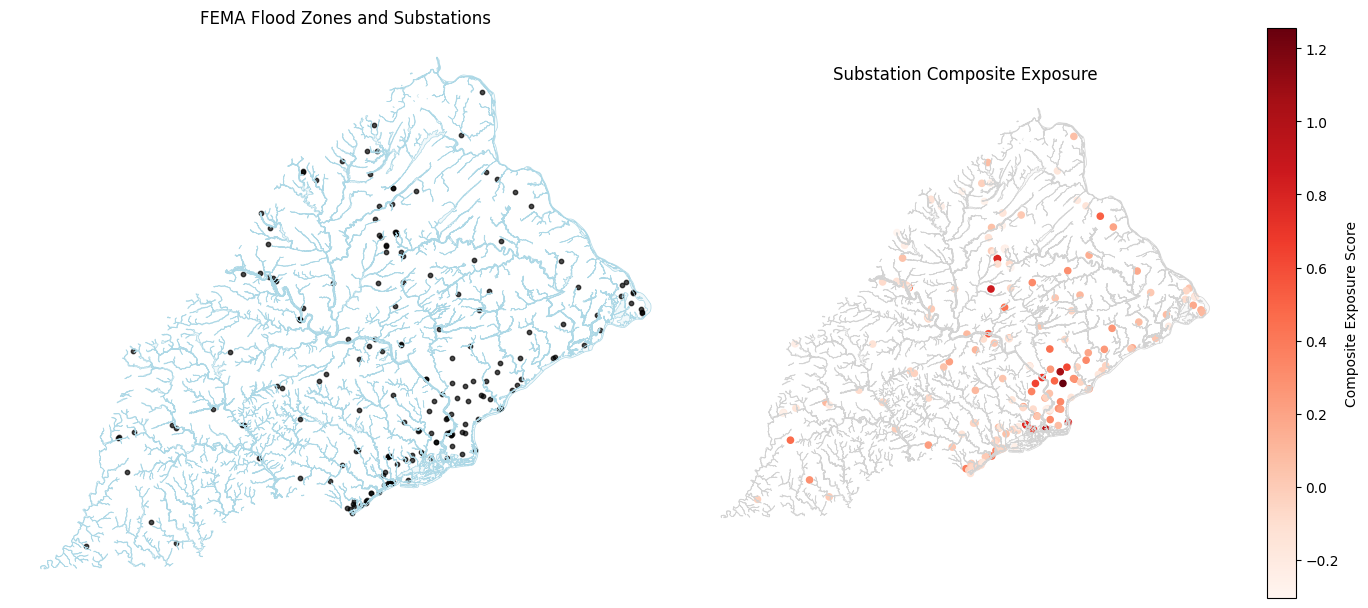

In [93]:
#Step 4.7: Visualizations (Side by Side Maps)

# Create a figure with two side-by-side axes
fig, (ax_left, ax_right) = plt.subplots(
    1, 2, figsize=(14, 6), sharex=True, sharey=True
)

# 1A. Left: Flood zones + all substations (no risk coloring)
flood_high_2272.boundary.plot(ax=ax_left, linewidth=0.5, color="lightblue")
flood_high_2272.plot(ax=ax_left, alpha=0.15, color="lightblue")

df_ranked_geo_2272.plot(
    ax=ax_left,
    markersize=10,
    color="black",
    alpha=0.7,
)

ax_left.set_title("FEMA Flood Zones and Substations")
ax_left.set_axis_off()

# 1B. Right: Same base, but color substations by exposure_score
flood_high_2272.boundary.plot(ax=ax_right, linewidth=0.5, color="lightgray")
flood_high_2272.plot(ax=ax_right, alpha=0.1, color="lightgray")

exposure_plot = df_ranked_geo_2272.plot(
    ax=ax_right,
    column="exposure_score",
    cmap="Reds",
    markersize=20,
    legend=True,
    legend_kwds={"label": "Composite Exposure Score"},
)

ax_right.set_title("Substation Composite Exposure")
ax_right.set_axis_off()

plt.tight_layout()
plt.show()


In [94]:
#Step 4.8: Smoooooth Operator
operator_risk = (
    df_ranked.groupby("operator_clean")
    .agg(
        mean_exposure=("exposure_score", "mean"),
        max_exposure=("exposure_score", "max"),
        n_substations=("exposure_score", "size"),
    )
    .sort_values("mean_exposure", ascending=False)
)

operator_risk


,mean_exposure,max_exposure,n_substations
operator_clean,,,
PECO,0.142402,1.255467,116
unknown,-0.008504,1.052373,25
Amtrak,-0.028127,0.245826,14
other_operator,-0.102368,0.770354,28
SEPTA,-0.148003,-0.147459,2


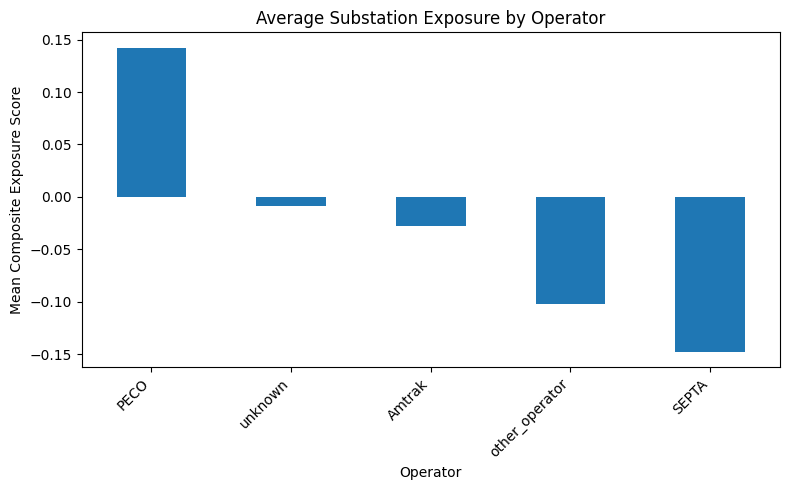

In [95]:
fig, ax = plt.subplots(figsize=(8, 5))

operator_risk["mean_exposure"].plot(
    kind="bar",
    ax=ax,
)

ax.set_ylabel("Mean Composite Exposure Score")
ax.set_xlabel("Operator")
ax.set_title("Average Substation Exposure by Operator")

# Optionally rotate labels to avoid overlap
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [96]:
#Step 4.9: T-20 Highest Risk Viz
# Take top 20 by exposure_score
top20 = df_ranked_geo_2272.sort_values("exposure_score", ascending=False).head(20)

top20

,exposure_score,name,operator_clean,substation_class,voltage_class,geometry
27,1.255467,North Philadelphia Substation,PECO,distribution,transmission,POINT (2697149.013 253616.399)
41,1.052373,Wayne Junction Substation,unknown,unknown,transmission,POINT (2694991.017 262999.51)
25,0.939013,Penrose Substation,PECO,unknown,transmission,POINT (2683386.498 216971.785)
65,0.881454,Elroy Substation PECO,PECO,transmission,extra_high_voltage,POINT (2644666.907 353530.385)
97,0.851097,Center Point Substation,PECO,transmission,extra_high_voltage,POINT (2639317.544 329499.933)
28,0.783115,Southwark Substation,PECO,generation,subtransmission_low,POINT (2701489.693 222395.236)
181,0.781180,None,PECO,transmission,subtransmission_high,POINT (2667233.038 220691.132)
66,0.770354,Elroy Substation PPL,other_operator,transmission,extra_high_voltage,POINT (2644342.68 354017.756)
166,0.751285,None,PECO,transmission,subtransmission_low,POINT (2668050.429 219734.578)
23,0.685824,Penncoyd Substation,PECO,unknown,subtransmission_low,POINT (2680499.947 258314.744)


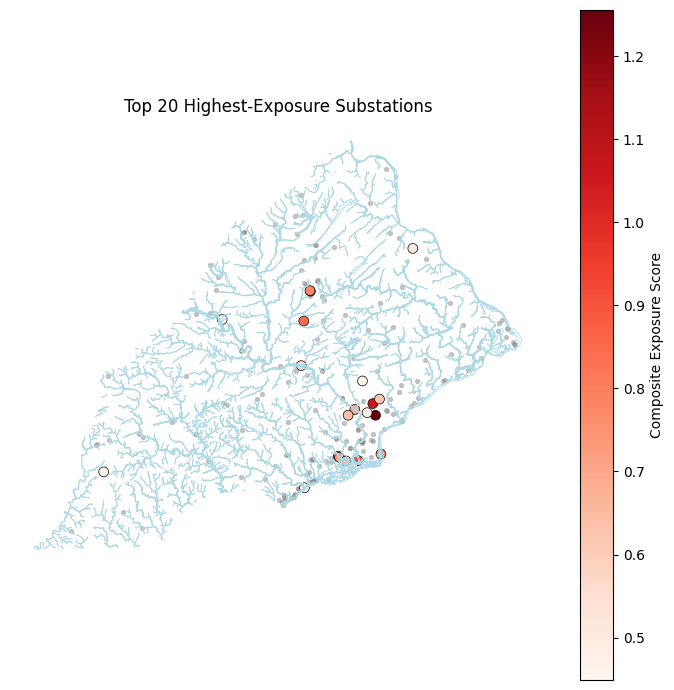

In [98]:
fig, ax = plt.subplots(figsize=(7, 7))

# Base flood polygons
flood_high_2272.boundary.plot(ax=ax, linewidth=0.5, color="lightblue")
flood_high_2272.plot(ax=ax, alpha=0.15, color="lightblue")

# All substations as faint background
df_ranked_geo_2272.plot(
    ax=ax,
    markersize=8,
    color="gray",
    alpha=0.4,
)

# Top 20 highlighted, sized and colored by exposure score
top_plot = top20.plot(
    ax=ax,
    column="exposure_score",
    cmap="Reds",
    markersize=50,
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={"label": "Composite Exposure Score"},
)

ax.set_title("Top 20 Highest-Exposure Substations")
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Analyzing the Rapid Deployment Network

In [15]:
import glob
data_root = r"C:\Users\Owner\Downloads\Geospatial Data Science\Final Project\Data\PA-RDN-DR_2022_Table_Shapefile"
rdn_dir   = os.path.join(data_root, "DR_2022_Table_Shapefile")

# 1. List shapefiles; there should be just one
rdn_shps = glob.glob(os.path.join(rdn_dir, "*.shp"))
rdn_shps

['C:\\Users\\Owner\\Downloads\\Geospatial Data Science\\Final Project\\Data\\PA-RDN-DR_2022_Table_Shapefile\\DR_2022_Table_Shapefile\\DR_2022_Table_Shapefile.shp']

In [16]:
rdn = gpd.read_file(rdn_shps[0])
rdn.head(), rdn.crs, rdn.columns

(   OBJECTID  BRKEY CTY_CODE ST_RT_NO SEG_NO  OFFSET ADMIN_JURI  DEC_LAT  \
 0   3918888  41599       04     0068   0570    2079          1  40.7783   
 1   3918920  36253       64     0711   0420       0          1  40.3367   
 2   3918944  18488       30     7203   0634       0          6  39.8883   
 3   3918952  44493       03     0058   0020      66          1  41.1399   
 4   3918992  46710       64     2043   0090     955       None  40.2119   
 
    DEC_LONG       BRIDGE_ID  ... TOP50 TOPCOUNTY TOPHUC8 TOPSUM    COUNTY_NAM  \
 0  -80.1604  04006805702079  ...   0.0       0.0     0.0    0.0        BEAVER   
 1  -79.1358  64071104200000  ...   0.0       0.0     0.0    0.0  WESTMORELAND   
 2  -80.0480  30720306342015  ...   0.0       0.0     0.0    0.0        GREENE   
 3  -79.6810  03005800200066  ...   0.0       0.0     0.0    0.0     ARMSTRONG   
 4  -79.2781  64204300900955  ...   0.0       0.0     0.0    0.0  WESTMORELAND   
 
    COUNTY_NUM  FIPS_COUNT      HUC8            

In [17]:
rdn.shape

(27429, 56)

**\[1]:** Please refer to the Notes and Appendix File for a breakdown of the data cleaning process.